In [1]:
import logging
from pathlib import Path
import re

if True:

    data_root = Path("../data/raw/datasets_4Hz")

    samples = []

    for verse_dir in data_root.glob("v*"):
        verse_match = re.fullmatch(r"v(\d+)", verse_dir.name)
        if not verse_match:
            logging.warning(
                "The dir `%s` is not verse_id formatted but is in the verse_ids dir",
                str(verse_dir),
            )
            continue

        verse_id = int(verse_match.group(1))
        dataset_dir = verse_dir / "4hz_datasets"

        for participant_file in dataset_dir.glob("p*.set"):
            participant_match = re.fullmatch(r"^p(\d+)\.set$", participant_file.name)
            if not participant_match:
                logging.warning(
                    "The file `%s` is not participant_id formatted but is in the participant_ids dir",
                    str(verse_dir),
                )
                continue

            participant_id = int(participant_match.group(1))

            break

participant_id, verse_id

(12, 23)

In [2]:
import mne

sample = mne.io.read_raw_eeglab(participant_file, verbose="ERROR")
print(participant_file)
sample


../data/raw/datasets_4Hz/v23/4hz_datasets/p12.set


<RawEEGLAB | p12.fdt, 18 x 910 (3.6 s), ~25 KiB, data not loaded>

In [3]:
sample.ch_names

['P7',
 'P4',
 'Pz',
 'P3',
 'P8',
 'O1',
 'O2',
 'T8',
 'F8',
 'C4',
 'F4',
 'Fp2',
 'Fz',
 'C3',
 'F3',
 'Fp1',
 'T7',
 'F7']

np.float64(3.5546875)

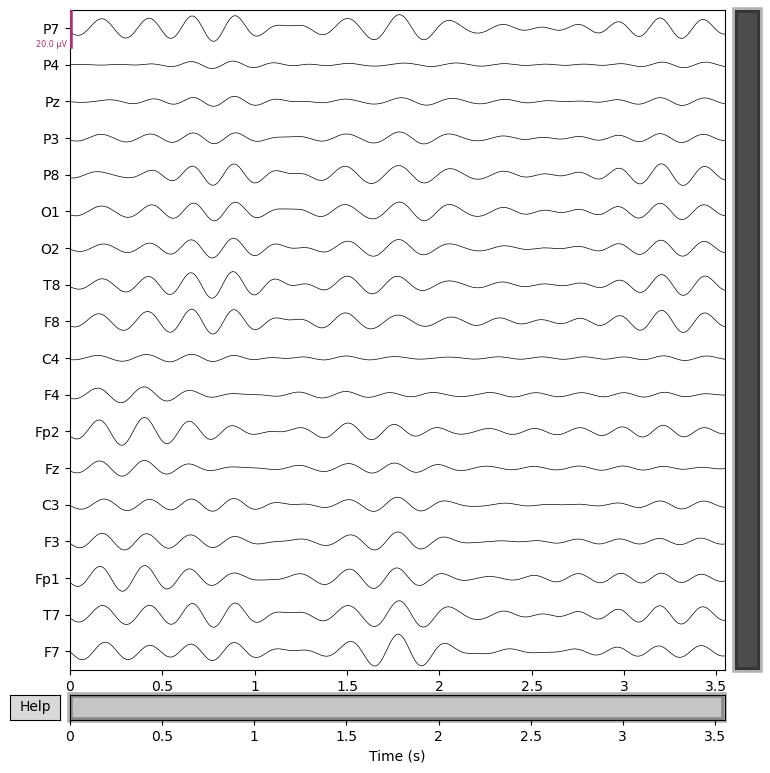

In [14]:
a = sample.plot(
    duration=10,
    n_channels=20,
    scalings={"eeg": 10e-6},  # ±100 µV
    remove_dc=False,
    proj=False,
)

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


/home/tu/micromamba/envs/nbm/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


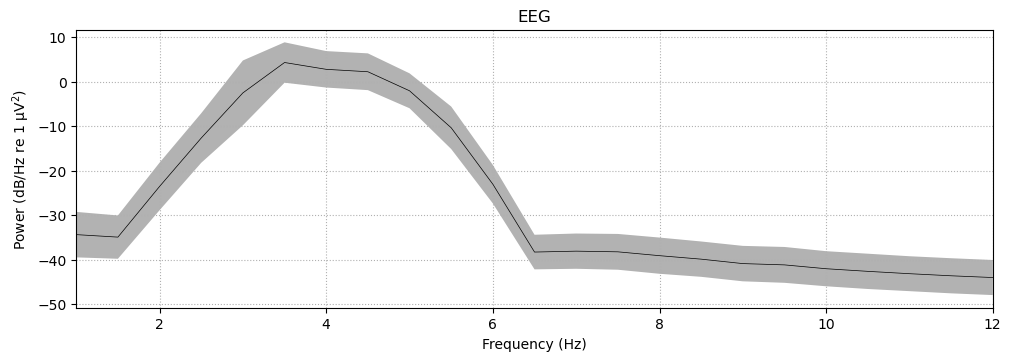

In [9]:
import matplotlib.pyplot as plt

# raw is your existing mne.io.Raw object
raw_eeg = sample

spectrum = raw_eeg.compute_psd(
    method="welch",
    fmin=1,
    fmax=12,
    n_fft=512,
    n_overlap=256,
)

spectrum.plot(
    average=True,
    dB=True,
)

In [10]:
sample.info

<Info | 8 non-empty values
 bads: []
 ch_names: P7, P4, Pz, P3, P8, O1, O2, T8, F8, C4, F4, Fp2, Fz, C3, F3, ...
 chs: 18 EEG
 custom_ref_applied: False
 dig: 21 items (3 Cardinal, 18 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 18
 projs: []
 sfreq: 256.0 Hz
>

samples: 700
duration_s:


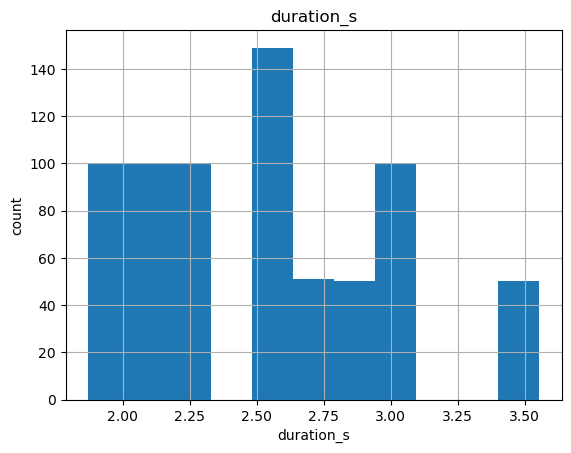

sfreq:
256.0
n_times:


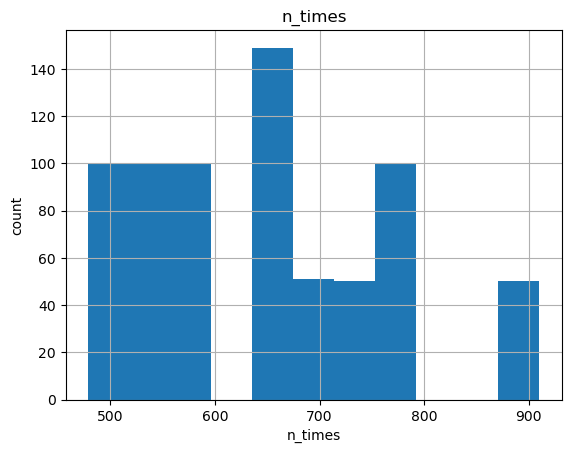

n_channels:


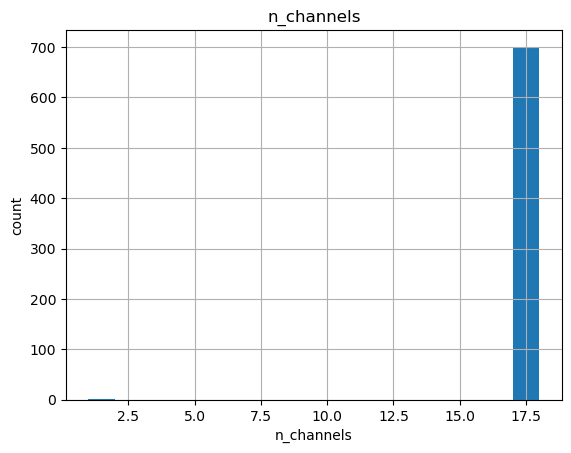

channels:


P7    699
Cz      1
Name: count, dtype: int64

,participant,line,duration_s,sfreq,n_times,n_channels,channels
0,12,7,2.289062,256.0,586,18,"(P7, P4, Pz, P3, P8, O1, O2, T8, F8, C4, F4, F..."
1,52,7,2.289062,256.0,586,18,"(P7, P4, Pz, P3, P8, O1, O2, T8, F8, C4, F4, F..."
2,11,7,2.289062,256.0,586,18,"(P7, P4, Pz, P3, P8, O1, O2, T8, F8, C4, F4, F..."
3,41,7,2.289062,256.0,586,18,"(P7, P4, Pz, P3, P8, O1, O2, T8, F8, C4, F4, F..."
4,30,7,2.289062,256.0,586,18,"(P7, P4, Pz, P3, P8, O1, O2, T8, F8, C4, F4, F..."
...,...,...,...,...,...,...,...
695,15,23,3.554688,256.0,910,18,"(P7, P4, Pz, P3, P8, O1, O2, T8, F8, C4, F4, F..."
696,56,23,3.554688,256.0,910,18,"(P7, P4, Pz, P3, P8, O1, O2, T8, F8, C4, F4, F..."
697,19,23,3.554688,256.0,910,18,"(P7, P4, Pz, P3, P8, O1, O2, T8, F8, C4, F4, F..."
698,39,23,3.554688,256.0,910,18,"(P7, P4, Pz, P3, P8, O1, O2, T8, F8, C4, F4, F..."


In [3]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

from adapt_eeg import data_reader

samples = data_reader.read_raw_data(data_root)

raw_summary = pd.DataFrame(
    [
        {
            "participant": sample.participant,
            "line": sample.line,
            "duration_s": sample.data.n_times / sample.data.info["sfreq"],
            "sfreq": sample.data.info["sfreq"],
            "n_times": sample.data.n_times,
            "n_channels": len(sample.data.ch_names),
            "channels": tuple(sample.data.ch_names),
        }
        for sample in samples
    ]
)


def print_uniform_or_histogram(df: pd.DataFrame, column: str, bins: int | str = "auto") -> None:
    values = df[column].dropna()
    unique = values.unique()
    print(f"{column}:")
    if len(unique) == 1:
        print(unique[0])
        return

    if pd.api.types.is_numeric_dtype(values):
        ax = values.hist(bins=bins)
        ax.set_title(column)
        ax.set_xlabel(column)
        ax.set_ylabel("count")
        plt.show()
    else:
        counts = Counter(values)
        display(pd.Series(counts).sort_values(ascending=False).rename("count"))


print(f"samples: {len(raw_summary)}")
for column in ["duration_s", "sfreq", "n_times", "n_channels", "channels"]:
    print_uniform_or_histogram(raw_summary, column)

raw_summary

In [4]:
raw_summary[raw_summary["n_channels"] != 18]

,participant,line,duration_s,sfreq,n_times,n_channels,channels
233,2,1,2.511719,256.0,643,1,"(Cz,)"


In [5]:
raw_summary["duration_s"].min()

1.87109375

In [8]:
raw_summary[raw_summary["duration_s"] <= 2.5]["line"].unique()

array([ 7,  6,  9,  8, 27, 30])